# Évaluation — Analyse approfondie des modèles

Ce notebook complète **`03_Modeling.ipynb`**. Il présente une évaluation approfondie des performances des modèles développés et une analyse détaillée du **modèle final retenu : Random Forest entraîné sur les données rééquilibrées par Random Under Sampling (RUS).**.

L'objectif est d'évaluer la capacité du modèle à détecter les clients susceptibles de résilier, d'analyser ses erreurs de prédiction et d'expliquer ses décisions grâce à des techniques d'interprétabilité.

## Plan

1. Chargement des données et des modèles
2. Matrices de confusion — comparaison des modèles
3. Courbes ROC comparatives
4. Courbes Precision-Recall
5. Analyse des erreurs (Faux Positifs et Faux Négatifs)
6. Optimisation du seuil de décision
7. Importance des variables (Feature Importance)
8. Permutation Importance
9. Explicabilité avec SHAP (analyse globale et locale)
10. Synthèse des résultats et recommandations métier

## 1. Chargement des modèles et des données

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    average_precision_score
)
from sklearn.inspection import permutation_importance

print('✅ Librairies importées !')

✅ Librairies importées !


In [ ]:
# Chargement des données de test
X_test = np.load('../models/X_test_prepared.npy')
y_test = np.load('../models/y_test.npy')

# Chargement des modèles entraînés
best_lr = joblib.load('../models/logistic_regression.pkl')
best_rf = joblib.load('../models/random_forest.pkl')
best_xgb = joblib.load('../models/xgboost.pkl')
best_mlp = joblib.load('../models/mlp.pkl')

# Chargement du modèle final retenu
best_model = joblib.load('../models/best_model.pkl')

# Liste des modèles à comparer
models = [
    (best_lr, 'Régression Logistique'),
    (best_rf, 'Random Forest'),
    (best_xgb, 'XGBoost'),
    (best_mlp, 'MLP'),
]

print("✅ Données et modèles chargés !")
print(f"   X_test : {X_test.shape} | y_test : {y_test.shape}")
print(f"   Churners dans le jeu de test : {y_test.sum()} / {len(y_test)} ({y_test.mean()*100:.1f}%)")
print("   Modèle final retenu : Random Forest")

✅ Données et modèles chargés !
   X_test : (2000, 51) | y_test : (2000,)
   Churners dans le jeu de test : 204 / 2000 (10.2%)
   Modèle final retenu : Random Forest


In [ ]:
# Chargement du pipeline de prétraitement
preprocessor = joblib.load('../models/preprocessor.pkl')

# Variables numériques
num_features = list(preprocessor.transformers_[0][2])

# Variables catégorielles après One-Hot Encoding
cat_features = preprocessor.transformers_[1][1]['onehot'] \
    .get_feature_names_out(
        preprocessor.transformers_[1][2]
    ).tolist()

# Liste complète des variables après prétraitement
all_features = num_features + cat_features

print(f"✅ {len(all_features)} variables après prétraitement")
print(f"   • {len(num_features)} variables numériques")
print(f"   • {len(cat_features)} variables catégorielles (One-Hot Encoding)")

✅ 51 variables après prétraitement
   • 19 variables numériques
   • 32 variables catégorielles (One-Hot Encoding)


## 2. Matrices de confusion — Comparaison des modèles

La **matrice de confusion** permet d'analyser les performances d'un modèle de classification en comparant les prédictions aux valeurs réelles. Elle distingue quatre types de prédictions :

- **Vrais Positifs (VP)** : churners correctement détectés ;
- **Vrais Négatifs (VN)** : clients fidèles correctement identifiés ;
- **Faux Positifs (FP)** : clients fidèles prédits à tort comme churners ;
- **Faux Négatifs (FN)** : churners non détectés par le modèle.

Dans un contexte de **prédiction du churn**, les **faux négatifs (FN)** représentent l'erreur la plus coûteuse, car ils correspondent à des clients qui résilient sans avoir été identifiés. L'objectif est donc de limiter ces erreurs, ce qui explique l'importance accordée au **Recall** lors de la comparaison des modèles dans le notebook de modélisation.

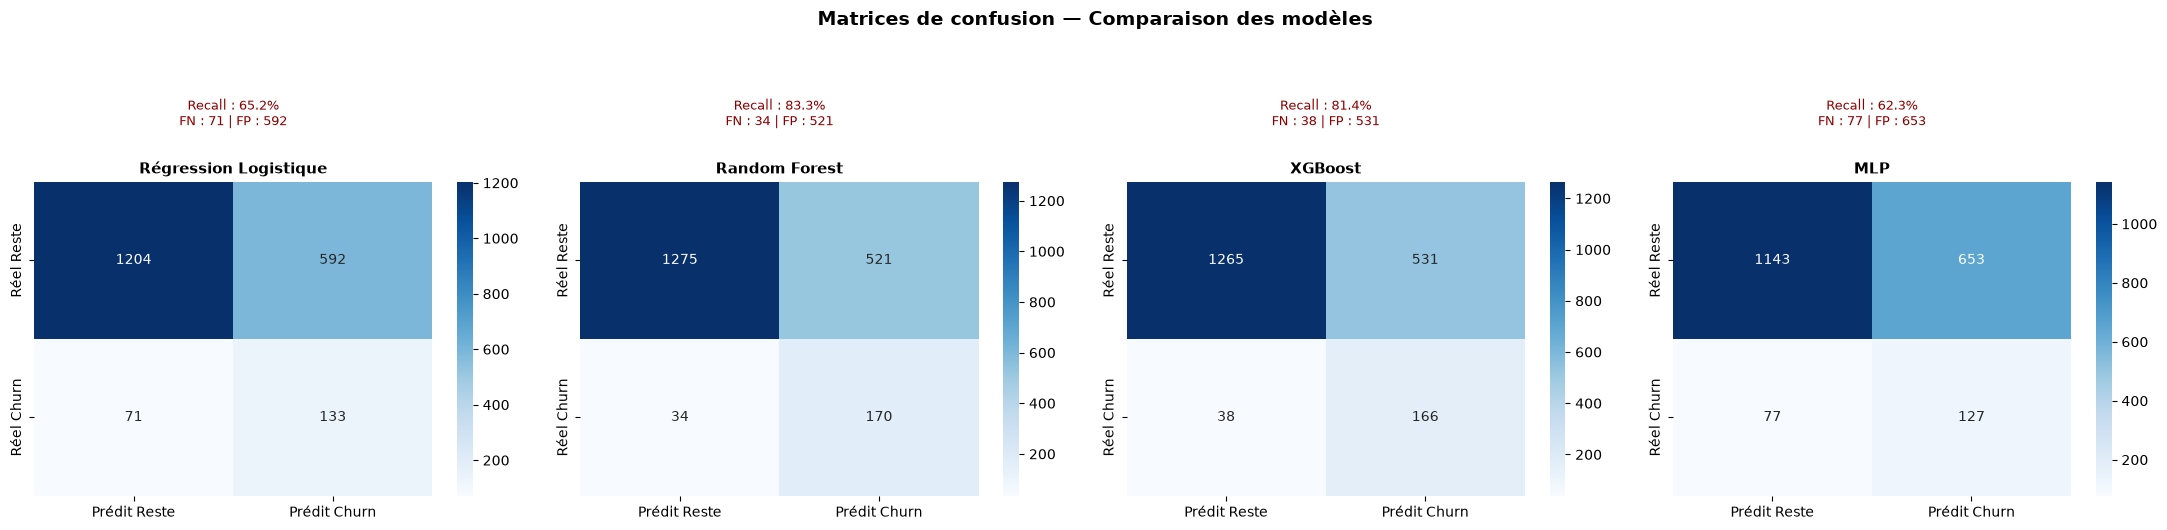

📊 Dans le contexte du churn, l'objectif principal est de réduire les faux négatifs (FN), car ils correspondent à des clients qui résilient sans avoir été détectés.


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (model, name) in zip(axes, models):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Prédit Reste', 'Prédit Churn'],
        yticklabels=['Réel Reste', 'Réel Churn']
    )

    ax.set_title(name, fontsize=11, fontweight='bold')

    ax.text(
        0.5,
        1.18,
        f"Recall : {rec:.1%}\nFN : {cm[1,0]} | FP : {cm[0,1]}",
        ha='center',
        transform=ax.transAxes,
        fontsize=9,
        color='darkred'
    )

plt.suptitle(
    'Matrices de confusion — Comparaison des modèles',
    fontsize=14,
    fontweight='bold',
    y=1.05
)

plt.tight_layout()
plt.show()

print("📊 Dans le contexte du churn, l'objectif principal est de réduire les faux négatifs (FN), car ils correspondent à des clients qui résilient sans avoir été détectés.")

In [ ]:
# Prédictions du modèle final
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=["Reste (0)", "Churn (1)"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df.round(3))

,precision,recall,f1-score,support
Reste (0),0.974,0.710,0.821,1796.000
Churn (1),0.246,0.833,0.380,204.000
accuracy,0.722,0.722,0.722,0.722
macro avg,0.610,0.772,0.601,2000.000
weighted avg,0.900,0.722,0.776,2000.000


## 3. Courbes ROC comparatives

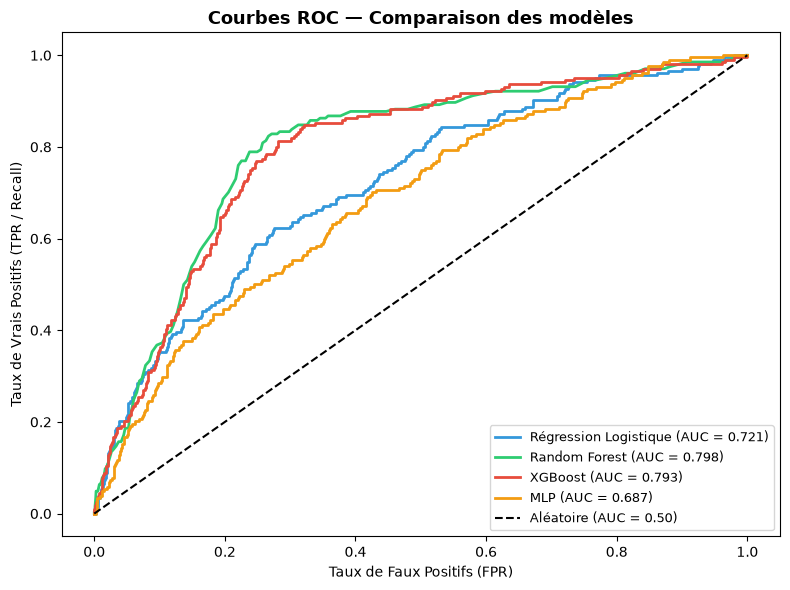

📊 Plus une courbe ROC est proche du coin supérieur gauche, meilleure est la capacité du modèle à distinguer les churners des clients fidèles.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (model, name), color in zip(models, colors):

    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)

    auc = roc_auc_score(y_test, y_proba)

    ax.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f'{name} (AUC = {auc:.3f})'
    )

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Aléatoire (AUC = 0.50)'
)

ax.set_title(
    'Courbes ROC — Comparaison des modèles',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR / Recall)')

ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print(
    "📊 Plus une courbe ROC est proche du coin supérieur gauche, "
    "meilleure est la capacité du modèle à distinguer les churners des clients fidèles."
)

## 4. Courbe Precision-Recall (Average Precision – AP)

La courbe Precision-Recall est particulièrement adaptée aux jeux de données déséquilibrés (90/10). Elle illustre le compromis entre la Precision et le Recall pour différents seuils de décision.

Les performances sont résumées par l'**Average Precision (AP)**, qui correspond à une synthèse de la courbe Precision-Recall. Plus l'AP est élevée, meilleur est le modèle pour détecter les churners tout en limitant les fausses alarmes.

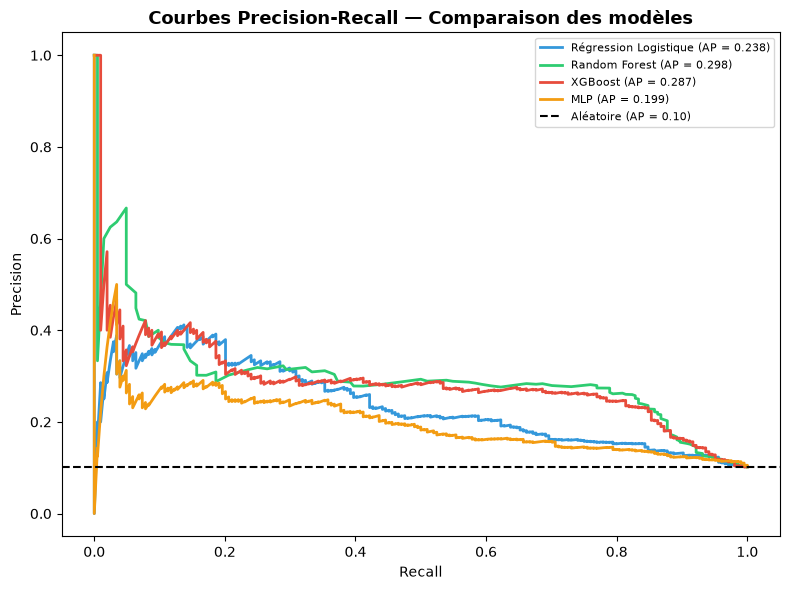

📊 Plus la courbe Precision-Recall est proche du coin supérieur droit, meilleur est le compromis entre Precision et Recall pour détecter les churners.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (model, name), color in zip(models, colors):

    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    ap = average_precision_score(y_test, y_proba)

    ax.plot(
        recall,
        precision,
        color=color,
        linewidth=2,
        label=f"{name} (AP = {ap:.3f})"
    )

# Performance d'un classifieur aléatoire
baseline = y_test.mean()

ax.axhline(
    y=baseline,
    color='black',
    linestyle='--',
    label=f"Aléatoire (AP = {baseline:.2f})"
)

ax.set_title(
    "Courbes Precision-Recall — Comparaison des modèles",
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print(
    "📊 Plus la courbe Precision-Recall est proche du coin supérieur droit, "
    "meilleur est le compromis entre Precision et Recall pour détecter les churners."
)

## 5. Analyse des erreurs

L'analyse des erreurs va au-delà des scores globaux : elle identifie **quels clients** sont mal prédits et **pourquoi**, pour formuler des recommandations réalistes.

📊 Analyse des erreurs — Random Forest + RUS (modèle final)
   ✅ Vrais Positifs (TP) :  170 — Churners correctement détectés
   ✅ Vrais Négatifs (TN) : 1275 — Clients fidèles correctement identifiés
   ⚠️ Faux Positifs (FP) :  521 — Clients fidèles classés à tort comme churners
   ❌ Faux Négatifs (FN) :   34 — Churners non détectés

💡 Analyse métier :
   • Un faux négatif (FN) correspond à un client qui résilie sans avoir été identifié.
     Il représente la perte métier la plus importante.
   • Un faux positif (FP) déclenche une action de rétention inutile,
     ce qui engendre un coût marketing mais reste moins critique.
   • Notre objectif est donc de limiter les faux négatifs, ce qui justifie
     l'importance accordée au Recall dans ce projet.


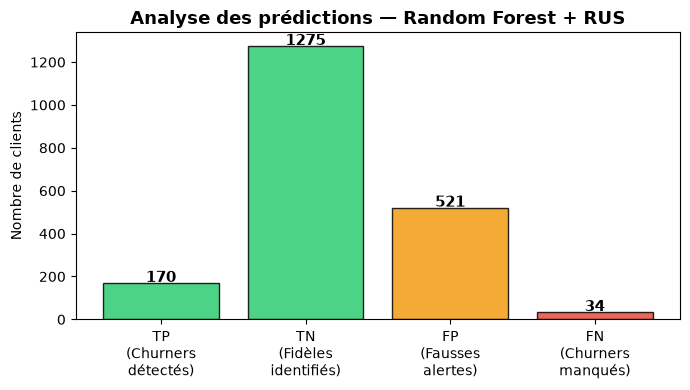

In [ ]:
# Prédictions du modèle final
y_pred_final = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:, 1]

# Calcul des composantes de la matrice de confusion
tp = int(((y_pred_final == 1) & (y_test == 1)).sum())
tn = int(((y_pred_final == 0) & (y_test == 0)).sum())
fp = int(((y_pred_final == 1) & (y_test == 0)).sum())
fn = int(((y_pred_final == 0) & (y_test == 1)).sum())

print("📊 Analyse des erreurs — Random Forest + RUS (modèle final)")
print("=" * 70)
print(f"   ✅ Vrais Positifs (TP) : {tp:4d} — Churners correctement détectés")
print(f"   ✅ Vrais Négatifs (TN) : {tn:4d} — Clients fidèles correctement identifiés")
print(f"   ⚠️ Faux Positifs (FP) : {fp:4d} — Clients fidèles classés à tort comme churners")
print(f"   ❌ Faux Négatifs (FN) : {fn:4d} — Churners non détectés")

print("\n💡 Analyse métier :")
print("   • Un faux négatif (FN) correspond à un client qui résilie sans avoir été identifié.")
print("     Il représente la perte métier la plus importante.")
print("   • Un faux positif (FP) déclenche une action de rétention inutile,")
print("     ce qui engendre un coût marketing mais reste moins critique.")
print("   • Notre objectif est donc de limiter les faux négatifs, ce qui justifie")
print("     l'importance accordée au Recall dans ce projet.")

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))

categories = [
    "TP\n(Churners\ndétectés)",
    "TN\n(Fidèles\nidentifiés)",
    "FP\n(Fausses\nalertes)",
    "FN\n(Churners\nmanqués)"
]

values = [tp, tn, fp, fn]

bar_colors = ['#2ecc71', '#2ecc71', '#f39c12', '#e74c3c']

bars = ax.bar(
    categories,
    values,
    color=bar_colors,
    edgecolor='black',
    alpha=0.85
)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    "Analyse des prédictions — Random Forest + RUS",
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

In [ ]:
print(f"\n📌 Synthèse :")
print(f"Le modèle détecte {tp} churners mais en manque {fn}.")
print("La priorité est de réduire les faux négatifs afin de maximiser les actions de rétention.")


📌 Synthèse :
Le modèle détecte 170 churners mais en manque 34.
La priorité est de réduire les faux négatifs afin de maximiser les actions de rétention.


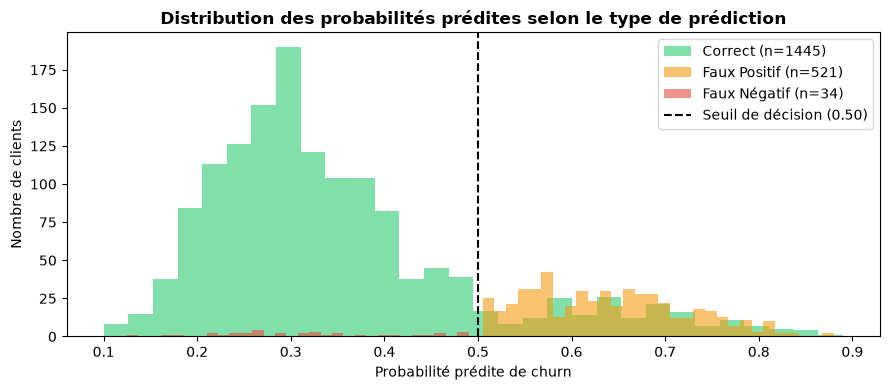

📊 Les faux négatifs présentent généralement une probabilité de churn proche du seuil de décision.
📊 Une diminution du seuil permettrait d'augmenter le Recall en détectant davantage de churners,
   mais entraînerait également une augmentation du nombre de faux positifs.


In [ ]:
# Distribution des probabilités prédites selon le type de prédiction

df_errors = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_final,
    "proba": y_proba_final
})

df_errors["type"] = "Correct"

df_errors.loc[
    (df_errors["y_pred"] == 1) & (df_errors["y_true"] == 0),
    "type"
] = "Faux Positif"

df_errors.loc[
    (df_errors["y_pred"] == 0) & (df_errors["y_true"] == 1),
    "type"
] = "Faux Négatif"

fig, ax = plt.subplots(figsize=(9, 4))

for etype, color in [
    ("Correct", "#2ecc71"),
    ("Faux Positif", "#f39c12"),
    ("Faux Négatif", "#e74c3c")
]:
    subset = df_errors[df_errors["type"] == etype]

    ax.hist(
        subset["proba"],
        bins=30,
        alpha=0.6,
        label=f"{etype} (n={len(subset)})",
        color=color
    )

ax.axvline(
    x=0.5,
    color="black",
    linestyle="--",
    label="Seuil de décision (0.50)"
)

ax.set_title(
    "Distribution des probabilités prédites selon le type de prédiction",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Probabilité prédite de churn")
ax.set_ylabel("Nombre de clients")

ax.legend()

plt.tight_layout()
plt.show()

print("📊 Les faux négatifs présentent généralement une probabilité estimée de churn proche du seuil de décision.")
print("📊 Une diminution du seuil permettrait d'augmenter le Recall en détectant davantage de churners,")
print("   mais entraînerait également une augmentation du nombre de faux positifs.")

## 6. Optimisation du seuil de décision

Par défaut, un modèle de classification utilise un **seuil de décision de 0,5** : lorsqu'un client présente une probabilité estimée de churn supérieure ou égale à 0,5, il est classé comme **churner**.

Cependant, ce seuil n'est pas toujours optimal. Dans un contexte de **prédiction du churn**, l'objectif est de détecter le plus grand nombre possible de clients à risque. Il peut donc être pertinent **d'abaisser le seuil de décision** afin d'augmenter le **Recall**, quitte à générer davantage de faux positifs et donc davantage d'actions de rétention.

Cette analyse permet d'identifier un compromis entre les performances du modèle et les contraintes métier.

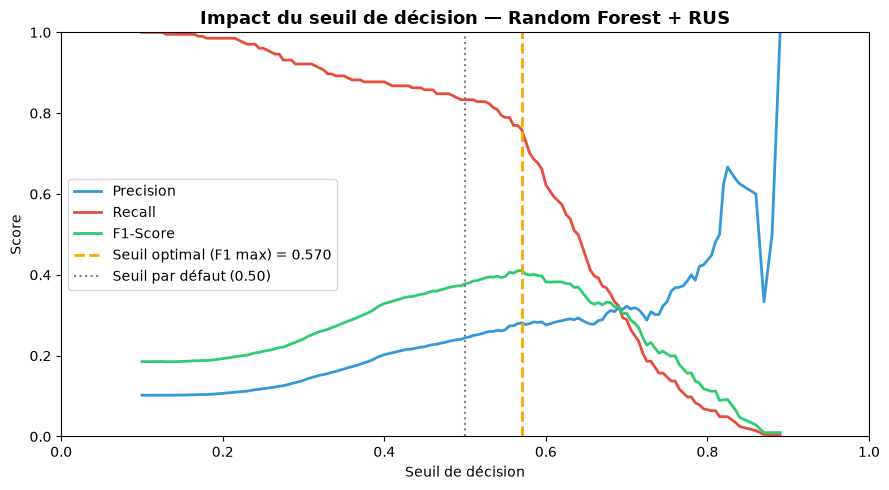


📊 Seuil optimal (F1 maximal) : 0.570
   Recall    : 0.7598 (vs 0.8333 au seuil 0.50)
   Precision : 0.2813 (vs 0.2460 au seuil 0.50)
   F1-Score  : 0.4106 (vs 0.3799 au seuil 0.50)


In [ ]:
precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_proba_final
)

f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)
best_thr = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    thresholds,
    precisions[:-1],
    label='Precision',
    color='#3498db',
    linewidth=2
)

ax.plot(
    thresholds,
    recalls[:-1],
    label='Recall',
    color='#e74c3c',
    linewidth=2
)

ax.plot(
    thresholds,
    f1_scores[:-1],
    label='F1-Score',
    color='#2ecc71',
    linewidth=2
)

ax.axvline(
    x=best_thr,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Seuil optimal (F1 max) = {best_thr:.3f}'
)

ax.axvline(
    x=0.5,
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label='Seuil par défaut (0.50)'
)

ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Score")

ax.set_title(
    "Impact du seuil de décision — Random Forest + RUS",
    fontsize=13,
    fontweight="bold"
)

ax.legend()

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Évaluation au seuil optimal
y_pred_opt = (y_proba_final >= best_thr).astype(int)

print(f"\n📊 Seuil optimal (F1 maximal) : {best_thr:.3f}")
print(f"   Recall    : {recall_score(y_test, y_pred_opt):.4f} (vs {recall_score(y_test, y_pred_final):.4f} au seuil 0.50)")
print(f"   Precision : {precision_score(y_test, y_pred_opt):.4f} (vs {precision_score(y_test, y_pred_final):.4f} au seuil 0.50)")
print(f"   F1-Score  : {f1_score(y_test, y_pred_opt):.4f} (vs {f1_score(y_test, y_pred_final):.4f} au seuil 0.50)")

💡 Analyse métier :

Le seuil de 0,57 maximise le F1-score en offrant un meilleur équilibre
entre Precision et Recall.

En revanche, si l'objectif métier est de détecter un maximum de churners,
un seuil plus faible (comme 0,50) est préférable, car il offre un Recall
plus élevé (0,833 contre 0,760), au prix d'un plus grand nombre de faux
positifs.

## 7. Importance des variables (Feature Importance)

La **Feature Importance** permet d'identifier les variables qui contribuent le plus aux décisions du **modèle Random Forest**.

Dans un Random Forest, l'importance d'une variable est calculée à partir de la **diminution moyenne de l'impureté (Mean Decrease in Impurity - MDI)**. À chaque division d'un arbre, la variable qui réduit le plus l'impureté (indice de Gini) est considérée comme plus importante. L'importance finale correspond à la moyenne de cette contribution sur l'ensemble des arbres de la forêt.

Cette analyse fournit une première interprétation globale du modèle et permet d'identifier les facteurs les plus influents dans la prédiction du churn.

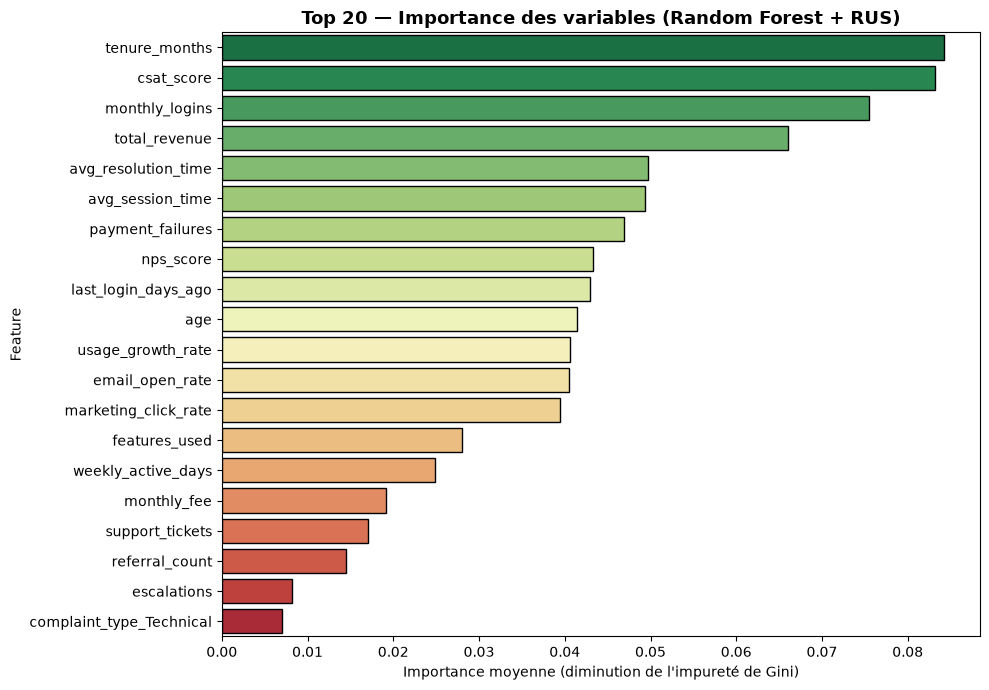


📊 Top 10 des variables les plus influentes :


,Feature,Importance
0,tenure_months,0.084219
1,csat_score,0.083239
2,monthly_logins,0.075462
3,total_revenue,0.066047
4,avg_resolution_time,0.049743
5,avg_session_time,0.049371
6,payment_failures,0.046923
7,nps_score,0.043272
8,last_login_days_ago,0.042953
9,age,0.041415


In [ ]:
# Importance des variables du modèle final (Random Forest + RUS)

importances = best_model.feature_importances_

feat_df = (
    pd.DataFrame({
        "Feature": all_features,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

top20 = feat_df.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature",
    palette="RdYlGn_r",
    edgecolor="black"
)

plt.title(
    "Top 20 — Importance des variables (Random Forest + RUS)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Importance moyenne (diminution de l'impureté de Gini)")

plt.tight_layout()
plt.show()

print("\n📊 Top 10 des variables les plus influentes :")

display(top20.head(10).reset_index(drop=True))

📌 Plus l'importance d'une variable est élevée, plus elle contribue aux décisions prises par le Random Forest.

## 8. Permutation Importance — Méthode agnostique

La **Permutation Importance** évalue l'importance d'une variable en mesurant la **baisse de performance du modèle** lorsque les valeurs de cette variable sont mélangées aléatoirement.

Contrairement à la **Feature Importance** native, cette méthode est **indépendante de l'algorithme** et peut être appliquée à tout modèle de Machine Learning. Elle fournit une estimation plus robuste de l'influence réelle des variables et limite le biais pouvant favoriser certaines variables, notamment celles présentant une forte cardinalité.

Cette analyse complète donc la Feature Importance afin d'obtenir une interprétation plus fiable du modèle.

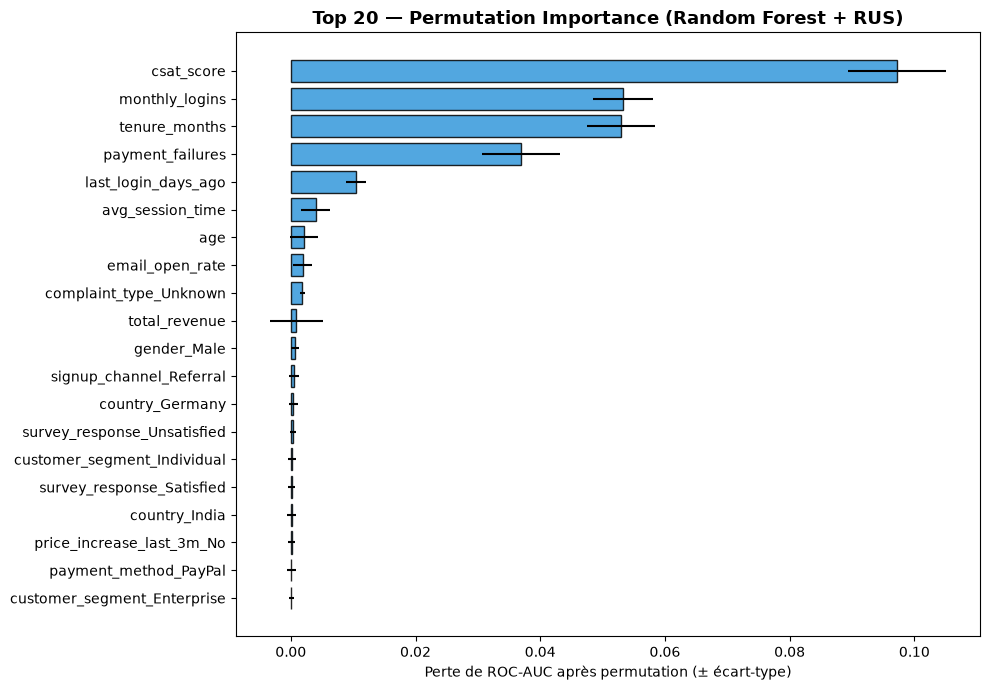

📊 Plus la perte de ROC-AUC est importante après permutation d'une variable,
   plus cette variable est essentielle aux prédictions du modèle.
📊 Les barres d'erreur représentent la variabilité de cette importance sur les différentes permutations.


In [ ]:
# Permutation Importance du modèle final (Random Forest + RUS)

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        'Feature': all_features,
        'Importance_mean': perm.importances_mean,
        'Importance_std': perm.importances_std
    })
    .sort_values('Importance_mean', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))

plt.barh(
    perm_df['Feature'][::-1],
    perm_df['Importance_mean'][::-1],
    xerr=perm_df['Importance_std'][::-1],
    color='#3498db',
    alpha=0.85,
    edgecolor='black'
)

plt.title(
    'Top 20 — Permutation Importance (Random Forest + RUS)',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel("Perte de ROC-AUC après permutation (± écart-type)")

plt.tight_layout()
plt.show()

print("📊 Plus la perte de ROC-AUC est importante après permutation d'une variable,")
print("   plus cette variable est essentielle aux prédictions du modèle.")
print("📊 Les barres d'erreur représentent la variabilité de cette importance sur les différentes permutations.")

📌 Les variables les plus importantes sont globalement les mêmes que celles obtenues avec la Feature Importance.
Cette cohérence renforce la confiance dans l'interprétation du modèle.

## 9. SHAP — Explicabilité locale et globale

Les **SHAP (SHapley Additive exPlanations)** permettent d'expliquer les décisions du modèle en attribuant à chaque variable sa contribution à une prédiction.

Contrairement à la **Feature Importance** ou à la **Permutation Importance**, qui fournissent une interprétation **globale** du modèle, SHAP permet d'expliquer **chaque prédiction individuellement**. Pour un client donné, il indique quelles variables **augmentent** ou **diminuent** le risque de churn, ainsi que l'intensité de leur contribution.

Cette méthode est particulièrement adaptée aux modèles d'arbres, tels que le **Random Forest**, et constitue un outil d'aide à la décision permettant de justifier les prédictions auprès des équipes métier.

In [ ]:
try:
    import shap
    shap_ok = True
    print("✅ SHAP disponible !")
except ImportError:
    shap_ok = False
    print("⚠️ SHAP n'est pas installé. Exécuter : pip install shap")

if shap_ok:

    # SHAP est optimisé pour les modèles d'arbres (Random Forest)
    explainer = shap.TreeExplainer(best_model)

    # On limite le nombre d'observations pour accélérer les calculs
    sample_size = min(500, X_test.shape[0])
    X_sample = X_test[:sample_size]

    # Calcul des valeurs SHAP
    shap_values = explainer.shap_values(X_sample)

    # Sélection de la classe positive (Churn = 1)
    shap_values_class1 = shap_values[:, :, 1]

    print(f"✅ Valeurs SHAP calculées sur {sample_size} clients du jeu de test.")

✅ SHAP disponible !
✅ Valeurs SHAP calculées sur 500 clients du jeu de test.


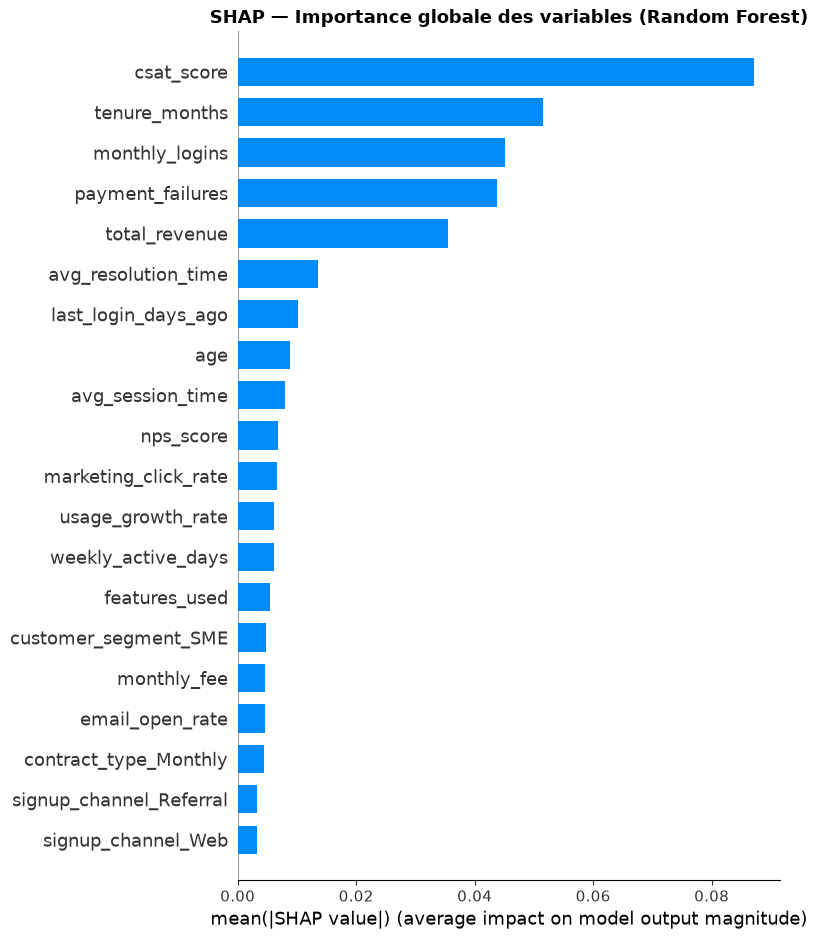

📊 SHAP classe les variables selon leur contribution moyenne absolue aux prédictions.
📊 Plus une variable est importante, plus elle influence la probabilité de churn.
📊 Les résultats peuvent être comparés à la Feature Importance et à la Permutation Importance.


In [ ]:
if shap_ok:

    # 9.1 Importance globale des variables selon SHAP
    plt.figure(figsize=(10, 7))

    shap.summary_plot(
        shap_values_class1,   # Classe positive : Churn = 1
        X_sample,
        feature_names=all_features,
        plot_type="bar",
        show=False
    )

    plt.title(
        "SHAP — Importance globale des variables (Random Forest)",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    print("📊 SHAP classe les variables selon leur contribution moyenne absolue aux prédictions.")
    print("📊 Plus une variable est importante, plus elle influence la probabilité estimée de churn.")
    print("📊 Les résultats peuvent être comparés à la Feature Importance et à la Permutation Importance.")

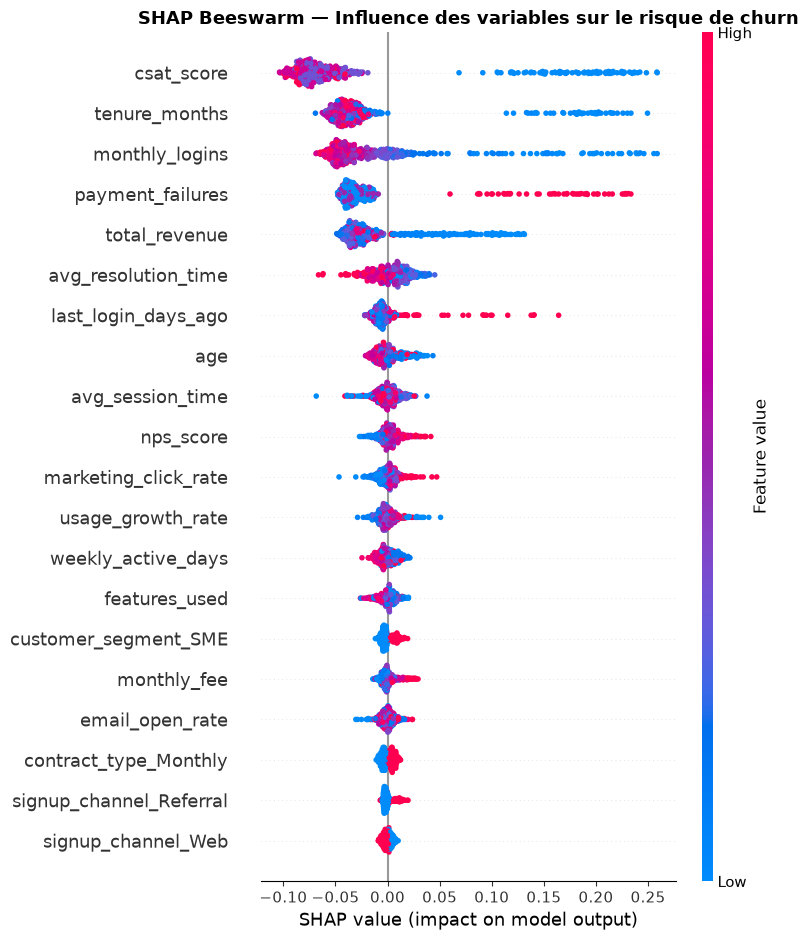

📊 Chaque point représente un client du jeu de test.
📊 Rouge = valeur élevée de la variable | Bleu = valeur faible.
📊 Les points à droite (SHAP > 0) augmentent le risque de churn.
📊 Les points à gauche (SHAP < 0) réduisent le risque de churn.


In [ ]:
if shap_ok:

    # 9.2 Beeswarm — influence des variables sur les prédictions
    plt.figure(figsize=(10, 8))

    shap.summary_plot(
        shap_values_class1,      # Classe positive : Churn = 1
        X_sample,
        feature_names=all_features,
        show=False
    )

    plt.title(
        "SHAP Beeswarm — Influence des variables sur le risque de churn",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    print("📊 Chaque point représente un client du jeu de test.")
    print("📊 Rouge = valeur élevée de la variable | Bleu = valeur faible.")
    print("📊 Les points à droite (SHAP > 0) augmentent le risque de churn.")
    print("📊 Les points à gauche (SHAP < 0) réduisent le risque de churn.")

🔍 Client le plus à risque dans l'échantillon :
   Index        : 195
   P(churn)     : 0.8700
   Churn réel   : 0


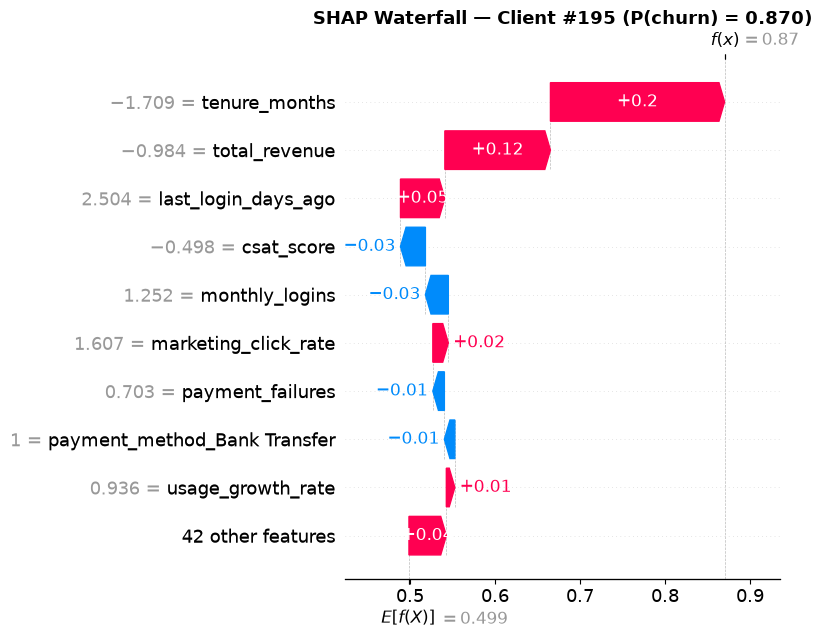


📊 Chaque barre représente la contribution d'une variable à la prédiction.
📊 Les barres rouges augmentent le risque de churn.
📊 Les barres bleues diminuent le risque de churn.


In [ ]:
if shap_ok:

    # 9.3 Waterfall — Explication locale d'un client à haut risque
    y_proba_sample = best_model.predict_proba(X_sample)[:, 1]
    high_risk_idx = np.argmax(y_proba_sample)

    print("🔍 Client le plus à risque dans l'échantillon :")
    print(f"   Index        : {high_risk_idx}")
    print(f"   P(churn)     : {y_proba_sample[high_risk_idx]:.4f}")
    print(f"   Churn réel   : {int(y_test[high_risk_idx])}")

    # Valeur de base pour la classe Churn (1)
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[1]

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_class1[high_risk_idx],
            base_values=base_value,
            data=X_sample[high_risk_idx],
            feature_names=all_features
        ),
        show=False
    )

    plt.title(
        f"SHAP Waterfall — Client #{high_risk_idx} (P(churn) = {y_proba_sample[high_risk_idx]:.3f})",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    print("\n📊 Chaque barre représente la contribution d'une variable à la prédiction.")
    print("📊 Les barres rouges augmentent le risque de churn.")
    print("📊 Les barres bleues diminuent le risque de churn.")

## 10. Synthèse et recommandations métier

### 10.1 Tableau récapitulatif final

In [ ]:
def get_metrics(model, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Modèle": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
        "PR-AUC": round(average_precision_score(y_test, y_proba), 4)
    }

final_results = pd.DataFrame([
    get_metrics(best_lr,  "Régression Logistique"),
    get_metrics(best_rf,  "Random Forest + RUS ✅"),
    get_metrics(best_xgb, "XGBoost"),
    get_metrics(best_mlp, "MLP (Deep Learning)")
]).set_index("Modèle")

print("📊 Tableau récapitulatif final — Comparaison des modèles")

display(
    final_results.style
        .highlight_max(axis=0, color="#d4f0d4")
        .highlight_min(axis=0, color="#f0d4d4")
        .format("{:.4f}")
)

print("\n🟢 Vert : meilleure valeur pour chaque métrique.")
print("🔴 Rouge : performance la plus faible.")

📊 Tableau récapitulatif final — Comparaison des modèles


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Modèle,,,,,,
Régression Logistique,0.6685,0.1834,0.6520,0.2863,0.7212,0.2381
Random Forest + RUS ✅,0.7225,0.2460,0.8333,0.3799,0.7981,0.2978
XGBoost,0.7155,0.2382,0.8137,0.3685,0.7927,0.2875
MLP (Deep Learning),0.6350,0.1628,0.6225,0.2581,0.6872,0.1993



🟢 Vert : meilleure valeur pour chaque métrique.
🔴 Rouge : performance la plus faible.


### 10.2 Interprétation des résultats SHAP — Logique métier

Les analyses **SHAP** permettent d'identifier les variables qui influencent le plus les prédictions du modèle et de comprendre les facteurs associés au risque de churn.

**Variables associées à une augmentation du risque de churn :**
- `payment_failures` élevé : peut traduire des difficultés ou des frictions liées au paiement.
- `support_tickets` élevé : peut refléter une insatisfaction ou des problèmes rencontrés avec le service.
- `nps_score` faible : les clients détracteurs présentent généralement un risque de churn plus élevé.
- `last_login_days_ago` élevé : une longue période d'inactivité peut être le signe d'un désengagement progressif.

**Variables associées à une diminution du risque de churn :**
- `tenure_months` élevé : les clients présents depuis longtemps sont généralement plus fidèles.
- `monthly_logins` élevé : un engagement régulier traduit une utilisation active du service.
- `total_revenue` élevé : les clients ayant une forte valeur économique sont souvent davantage investis dans le service.

**Attention à l'interprétation :**
Les analyses SHAP mettent en évidence des **associations** entre les variables et les prédictions du modèle. Elles ne démontrent pas une relation de causalité. Par exemple, un faible `nps_score` est fortement associé au churn, sans pour autant être la cause directe du départ du client.

---

### 10.3 Recommandations opérationnelles

À partir des résultats obtenus, plusieurs actions peuvent être proposées :

1. **Prioriser les campagnes de rétention** en ciblant les clients présentant une probabilité estimée de churn supérieure au seuil retenu, notamment ceux ayant une forte valeur (`total_revenue` élevé).
2. **Mettre en place des alertes automatiques** lorsqu'un client cumule plusieurs échecs de paiement (`payment_failures`).
3. **Déployer des campagnes de réengagement** auprès des clients inactifs depuis plusieurs semaines (`last_login_days_ago` élevé).
4. **Assurer un suivi proactif des clients ayant un faible NPS**, afin d'identifier rapidement les causes d'insatisfaction.
5. **Adapter le seuil de décision** selon les objectifs métier : un seuil plus faible favorise la détection des churners (Recall plus élevé), tandis qu'un seuil plus élevé limite les faux positifs et les coûts des campagnes marketing.

---

### 10.4 Limites du modèle

Malgré ses bonnes performances, le modèle présente plusieurs limites :

- **Jeu de données synthétique** : le dataset utilisé est artificiellement généré. Les performances observées peuvent différer sur des données réelles.
- **Évolution du comportement des clients** : les habitudes des utilisateurs évoluent dans le temps. Un réentraînement périodique du modèle est donc nécessaire.
- **Variables non observées** : certains facteurs influençant le churn (offres concurrentes, qualité du service, contexte économique, etc.) ne sont pas présents dans le jeu de données.
- **Variabilité des explications SHAP** : les valeurs SHAP peuvent légèrement varier selon le modèle entraîné, le découpage des données et l'échantillon analysé.

In [ ]:
from sklearn.metrics import precision_recall_curve

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
best_thr = thresholds[np.argmax(f1_scores)]

print("=" * 65)
print("        ✅ ÉVALUATION DU MODÈLE — SYNTHÈSE")
print("=" * 65)

print("Modèle retenu          : Random Forest + RUS")
print(f"Recall                 : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score               : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC                : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Seuil optimal (F1)     : {best_thr:.3f}")
print("Explicabilité          : SHAP (TreeExplainer)")
print("Application cible      : Dashboard Streamlit")

print("=" * 65)

        ✅ ÉVALUATION DU MODÈLE — SYNTHÈSE
Modèle retenu          : Random Forest + RUS
Recall                 : 0.8333
F1-Score               : 0.3799
ROC-AUC                : 0.7981
Seuil optimal (F1)     : 0.570
Explicabilité          : SHAP (TreeExplainer)
Application cible      : Dashboard Streamlit


# Conclusion

L'évaluation comparative des différents modèles de Machine Learning a permis d'identifier **Random Forest entraîné avec la stratégie Random Under Sampling (RUS)** comme le modèle le plus performant pour la prédiction du churn sur ce jeu de données.

Les différentes analyses réalisées (métriques de classification, matrices de confusion, courbes ROC et Precision-Recall, optimisation du seuil de décision, importance des variables, Permutation Importance et explications SHAP) montrent que ce modèle offre le meilleur compromis entre **performance prédictive**, **stabilité** et **interprétabilité**.

Les résultats obtenus permettront d'alimenter le développement du **dashboard interactif Streamlit**, afin d'aider les équipes métier à identifier les clients présentant un risque élevé de churn et à mettre en œuvre des actions de rétention ciblées.

Ce modèle sera utilisé dans le dashboard Streamlit afin de fournir des prédictions et d'aider les équipes métier dans leurs actions de rétention.